In [5]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Loaded statistics for 30 original dataset(s) and 2000 target dataset(s).


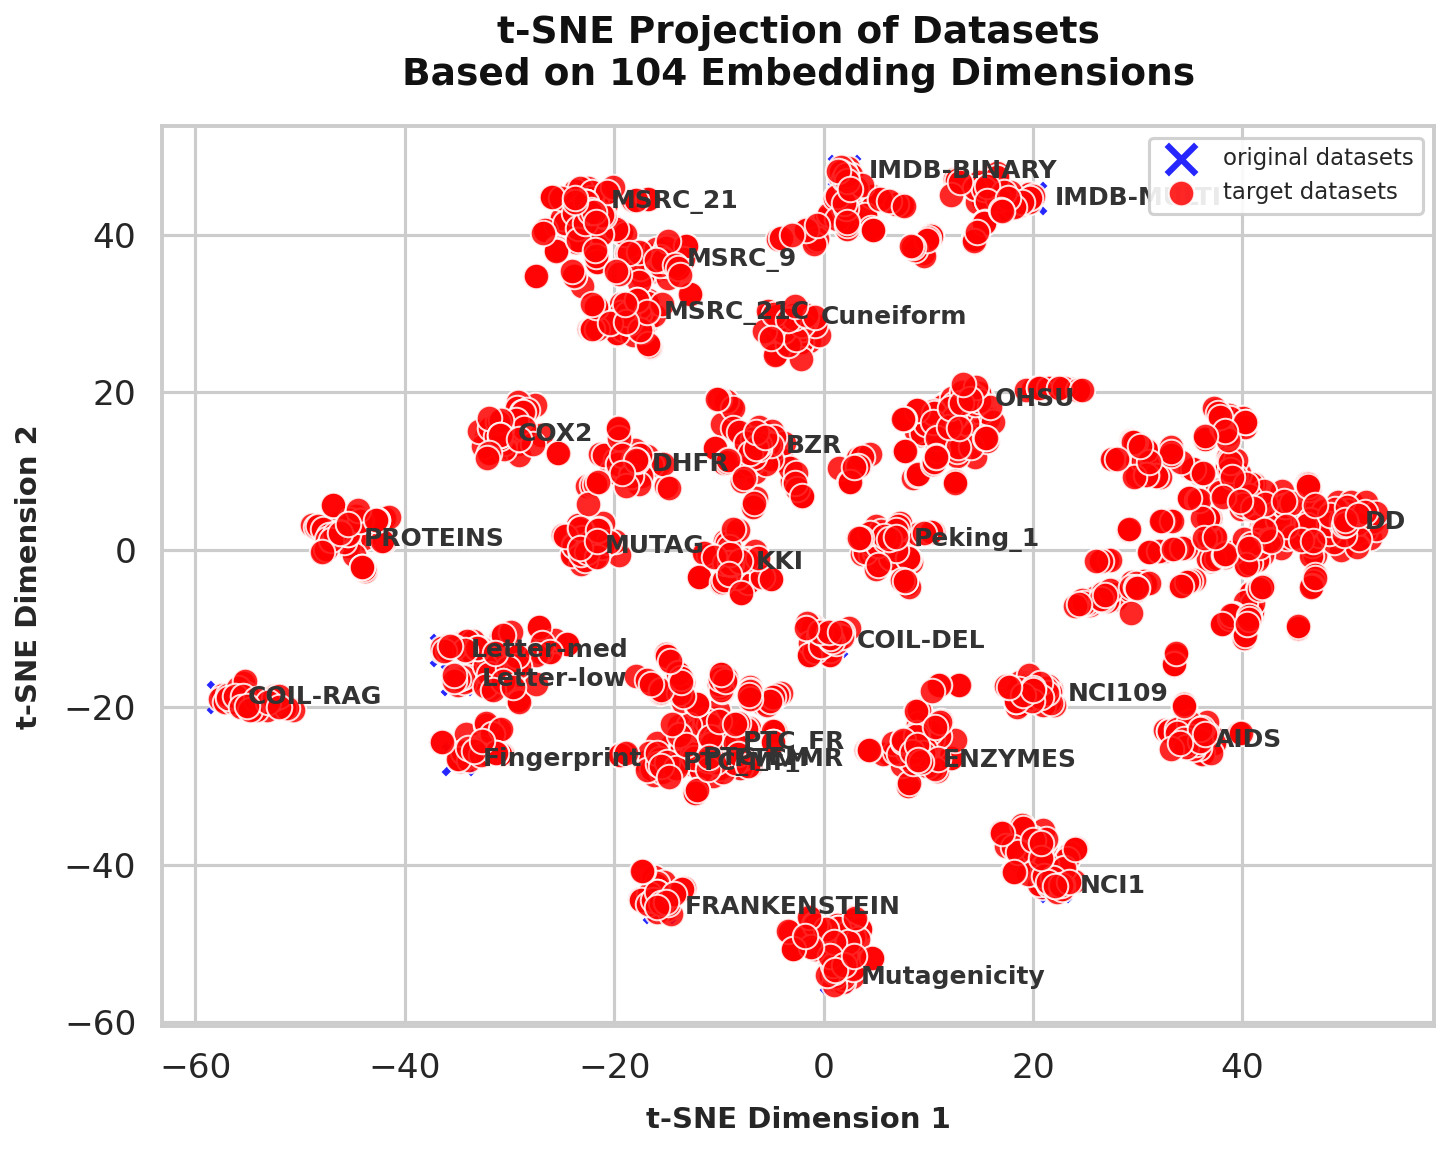

In [6]:
def plot_original_datasets_tsne() -> None:
    csv_path_orig = PROJECT_ROOT / "results" / "original_datasets_mean_stats.csv"
    csv_path_target = PROJECT_ROOT / "results" / "target_datasets_mean_stats.csv"
    
    if not csv_path_orig.exists():
        print(f"Error: CSV file not found at {csv_path_orig}. Please run Phase A of evaluate_flexibility.py first.")
        return

    df_orig = pd.read_csv(csv_path_orig)
    if df_orig.empty:
        print("Error: The original datasets CSV file is empty.")
        return

    # Load target datasets if they exist
    df_target = pd.read_csv(csv_path_target) if csv_path_target.exists() else pd.DataFrame()
    
    if not df_target.empty:
        df = pd.concat([df_orig, df_target], ignore_index=True)
        print(f"Loaded statistics for {len(df_orig)} original dataset(s) and {len(df_target)} target dataset(s).")
    else:
        df = df_orig
        print(f"Loaded statistics for {len(df_orig)} original dataset(s) (no target datasets found).")
    
    # Dynamically detect targeted features (check for embeddings first, then fall back)
    targeted_features = [c for c in df.columns if c.startswith("emb_")]
    is_embedding = len(targeted_features) > 0
    
    if not is_embedding:
        targeted_features = [
            "n_nodes_mean", "n_edges_mean",
            *(f"degree_moments_{i}_mean" for i in range(4)),
            *(f"annd_{i}_mean" for i in range(4)),
            *(f"eccentricity_{i}_mean" for i in range(4))
        ]
    
    missing_features = [f for f in targeted_features if f not in df.columns]
    if missing_features:
        print(f"Error: Missing features in CSV: {missing_features}")
        return

    X = df[targeted_features].values
    datasets = df["Dataset"].values

    if len(df) < 2:
        print("\nWarning: t-SNE requires at least 2 datasets to visualize distances.")
        if len(df) == 1:
            print(f"Only one dataset '{datasets[0]}' found. Here are the features:")
            display(df[["Dataset"] + targeted_features].T)
        return

    # Scale and apply t-SNE
    X_scaled = StandardScaler().fit_transform(X)
    perplexity = min(30, max(1, len(df) - 1))
    X_tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42).fit_transform(X_scaled)

    df_tsne = pd.DataFrame(X_tsne, columns=["t-SNE 1", "t-SNE 2"])
    df_tsne["Dataset"] = datasets

    # Separate original and target coordinates
    is_target = df_tsne["Dataset"].str.startswith("target_")
    df_tsne_orig = df_tsne[~is_target]
    df_tsne_target = df_tsne[is_target]

    # Plotting
    sns.set_theme(style="whitegrid", context="talk")
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    
    # Original datasets as blue 'x' markers
    sns.scatterplot(
        data=df_tsne_orig, x="t-SNE 1", y="t-SNE 2",
        color="blue", marker="x", s=200, alpha=0.85, linewidth=3,
        ax=ax, label="original datasets"
    )

    # Target datasets as red dots
    if not df_tsne_target.empty:
        sns.scatterplot(
            data=df_tsne_target, x="t-SNE 1", y="t-SNE 2",
            color="red", marker="o", s=150, alpha=0.85,
            ax=ax, label="target datasets"
        )

    # Annotate original points with dataset names
    for _, row in df_tsne_orig.iterrows():
        ax.annotate(
            row["Dataset"],
            xy=(row["t-SNE 1"], row["t-SNE 2"]),
            xytext=(12, 0), textcoords="offset points",
            fontsize=12, fontweight="bold", color="#333333", va="center"
        )

    # Styling title and labels
    title_text = (
        f"t-SNE Projection of Datasets\nBased on {len(targeted_features)} Embedding Dimensions"
        if is_embedding
        else "t-SNE Projection of Datasets\nBased on 14 Targeted Mean Statistics"
    )
    ax.set_title(title_text, fontsize=18, fontweight="bold", pad=20, color="#111111")
    ax.set_xlabel("t-SNE Dimension 1", fontsize=14, fontweight="bold", labelpad=10)
    ax.set_ylabel("t-SNE Dimension 2", fontsize=14, fontweight="bold", labelpad=10)
    ax.legend(fontsize=11, loc="upper right", framealpha=0.9, facecolor="white")
    
    plt.tight_layout()
    plt.show()


def plot_statistics_distributions() -> None:
    """Plots the distribution of the targeted statistics or embeddings for original vs synthetic datasets."""
    csv_path_orig = PROJECT_ROOT / "results" / "original_datasets_mean_stats.csv"
    csv_path_target = PROJECT_ROOT / "results" / "target_datasets_mean_stats.csv"
    
    if not csv_path_orig.exists():
        print(f"Error: CSV file not found at {csv_path_orig}. Please run Phase A of evaluate_flexibility.py first.")
        return

    df_orig = pd.read_csv(csv_path_orig)
    if df_orig.empty:
        print("Error: The original datasets CSV file is empty.")
        return

    if not csv_path_target.exists():
        print(f"Error: CSV file not found at {csv_path_target}. Please run Phase A of evaluate_flexibility.py first.")
        return

    df_target = pd.read_csv(csv_path_target)
    if df_target.empty:
        print("Error: The target datasets CSV file is empty.")
        return

    # Check if this is an embedding dataset
    embedding_cols = [c for c in df_orig.columns if c.startswith("emb_")]
    is_embedding = len(embedding_cols) > 0

    if is_embedding:
        discrete_features = ["n_nodes_mean"] if "n_nodes_mean" in df_orig.columns else []
        continuous_features = embedding_cols[:11]
        targeted_features = discrete_features + continuous_features
    else:
        discrete_features = ["n_nodes_mean", "n_edges_mean"]
        continuous_features = [
            *(f"degree_moments_{i}_mean" for i in range(4)),
            *(f"annd_{i}_mean" for i in range(4)),
            *(f"eccentricity_{i}_mean" for i in range(4))
        ]
        targeted_features = discrete_features + continuous_features

    missing_orig = [f for f in targeted_features if f not in df_orig.columns]
    missing_target = [f for f in targeted_features if f not in df_target.columns]
    if missing_orig or missing_target:
        print(f"Error: Missing features in CSVs. Original missing: {missing_orig}, Target missing: {missing_target}")
        return

    # Set up the plotting theme
    sns.set_theme(style="whitegrid", context="talk")
    
    if is_embedding:
        n_rows = 3
        n_cols = 4
        fig = plt.figure(figsize=(24, 5 * n_rows), dpi=150)
        fig.suptitle("Metric/Embedding Distribution: Original vs Synthetic (Target) Datasets", fontsize=22, fontweight="bold", y=0.96)
        gs = fig.add_gridspec(n_rows, n_cols, hspace=0.4, wspace=0.3)
        
        metrics_map = []
        all_features = targeted_features[:12]
        for i, feat in enumerate(all_features):
            row, col = divmod(i, n_cols)
            metrics_map.append((feat, fig.add_subplot(gs[row, col])))
    else:
        n_rows = 4
        fig = plt.figure(figsize=(24, 5 * n_rows), dpi=150)
        fig.suptitle("Metric Distribution: Original vs Synthetic (Target) Datasets", fontsize=22, fontweight="bold", y=0.96)
        gs = fig.add_gridspec(n_rows, 4, hspace=0.4, wspace=0.3)
        
        metrics_map = []
        metrics_map.append((discrete_features[0], fig.add_subplot(gs[0, :2])))
        metrics_map.append((discrete_features[1], fig.add_subplot(gs[0, 2:])))    
        for i, feat in enumerate(continuous_features):
            row, col = divmod(i, 4)
            metrics_map.append((feat, fig.add_subplot(gs[row + 1, col])))
        
    for feat, ax in metrics_map:
        # Plot distributions using histplot with kde=True for premium visualization
        for data, label, color in [(df_orig, "Original", "#3b82f6"), (df_target, "Synthetic (Target)", "#ef4444")]:
            sns.histplot(
                data=data, x=feat, ax=ax, label=label,
                color=color, alpha=0.35, stat="density", kde=True,
                element="bars", linewidth=0.5, edgecolor="white"
            )
        
        # Clean title styling
        clean_title = feat.replace("_mean", "").replace("_", " ").title()
        ax.set_title(clean_title, fontsize=16, fontweight="bold", pad=10)
        ax.set_xlabel("")
        ax.set_ylabel("Density", fontsize=12, alpha=0.7)
        ax.legend(fontsize=12, frameon=True, facecolor="white", framealpha=0.8)
        ax.grid(True, linestyle="--", alpha=0.3)
        sns.despine(ax=ax)
        
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

plot_original_datasets_tsne()
# plot_statistics_distributions()